In [3]:
#Importacion de librerias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

In [ ]:
#Se importan los archivos CSV a DataFrames de pandas

visits = pd.read_csv('visits_log_us.csv')
orders = pd.read_csv('orders_log_us.csv')
costs = pd.read_csv('costs_us.csv')

In [6]:
#Se muestran las columnas y las primeras filas de cada DF para entender su estructura

print("Columnas en visits:")
print(visits.columns.tolist())
print("\nPrimeras filas de visits:")
print(visits.head())

Columnas en visits:
['Device', 'End Ts', 'Source Id', 'Start Ts', 'Uid']

Primeras filas de visits:
    Device               End Ts  Source Id             Start Ts  \
0    touch  2017-12-20 17:38:00          4  2017-12-20 17:20:00   
1  desktop  2018-02-19 17:21:00          2  2018-02-19 16:53:00   
2    touch  2017-07-01 01:54:00          5  2017-07-01 01:54:00   
3  desktop  2018-05-20 11:23:00          9  2018-05-20 10:59:00   
4  desktop  2017-12-27 14:06:00          3  2017-12-27 14:06:00   

                    Uid  
0  16879256277535980062  
1    104060357244891740  
2   7459035603376831527  
3  16174680259334210214  
4   9969694820036681168  


In [7]:
print("Columnas en orders:")
print(orders.columns.tolist())
print("\nPrimeras filas de visits:")
print(orders.head())

Columnas en orders:
['Buy Ts', 'Revenue', 'Uid']

Primeras filas de visits:
                Buy Ts  Revenue                   Uid
0  2017-06-01 00:10:00    17.00  10329302124590727494
1  2017-06-01 00:25:00     0.55  11627257723692907447
2  2017-06-01 00:27:00     0.37  17903680561304213844
3  2017-06-01 00:29:00     0.55  16109239769442553005
4  2017-06-01 07:58:00     0.37  14200605875248379450


In [8]:
print("Columnas en costs:")
print(costs.columns.tolist())
print("\nPrimeras filas de visits:")
print(costs.head())

Columnas en costs:
['source_id', 'dt', 'costs']

Primeras filas de visits:
   source_id          dt  costs
0          1  2017-06-01  75.20
1          1  2017-06-02  62.25
2          1  2017-06-03  36.53
3          1  2017-06-04  55.00
4          1  2017-06-05  57.08


In [9]:
#Optimizar datos por DF a datetime

# Visits
visits['Start Ts'] = pd.to_datetime(visits['Start Ts'])
visits['End Ts'] = pd.to_datetime(visits['End Ts'])
visits.columns = visits.columns.str.lower().str.replace(' ', '_')

# Orders
orders['Buy Ts'] = pd.to_datetime(orders['Buy Ts'])
orders.columns = orders.columns.str.lower().str.replace(' ', '_')

# Costs
costs['dt'] = pd.to_datetime(costs['dt'])

In [10]:
#Crear nuevas columnas para separacion de los cohortes

visits['session_duration'] = (
    visits['end_ts'] - visits['start_ts']
).dt.total_seconds() / 60

visits['visit_date'] = visits['start_ts'].dt.date
visits['visit_week'] = visits['start_ts'].dt.to_period('W')
visits['visit_month'] = visits['start_ts'].dt.to_period('M')

orders['order_date'] = orders['buy_ts'].dt.date
orders['order_month'] = orders['buy_ts'].dt.to_period('M')

In [11]:
#Usuarios por día, semana y mes

dau = visits.groupby('visit_date')['uid'].nunique()
wau = visits.groupby('visit_week')['uid'].nunique()
mau = visits.groupby('visit_month')['uid'].nunique()

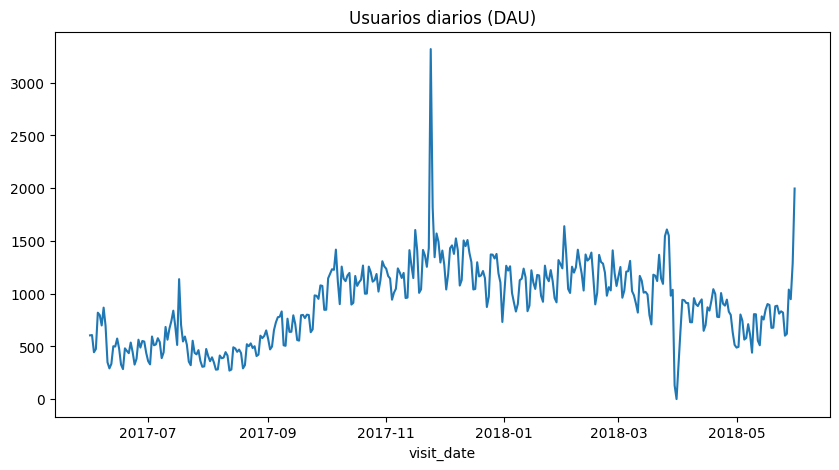

In [ ]:
#Generacion de DAU


plt.figure(figsize=(10,5))
dau.plot()
plt.title("Usuarios diarios (DAU)")
plt.show()


#El pico mas alto corresponde al mes de diciembre, para estas fechas existen festividades muy marcadas como navidad y año nuevo, lo cual sugiere que influyen a mayor demanda de eventos de entretenimiento. #El desplome mas fuerte fue en abril #El siguiente pico que mas destaca es en junio, muy probablemente para inicios de las vacaciones de verano, dejando en claro que en epocas de vacaciones es cuando la gente busca mas eventos

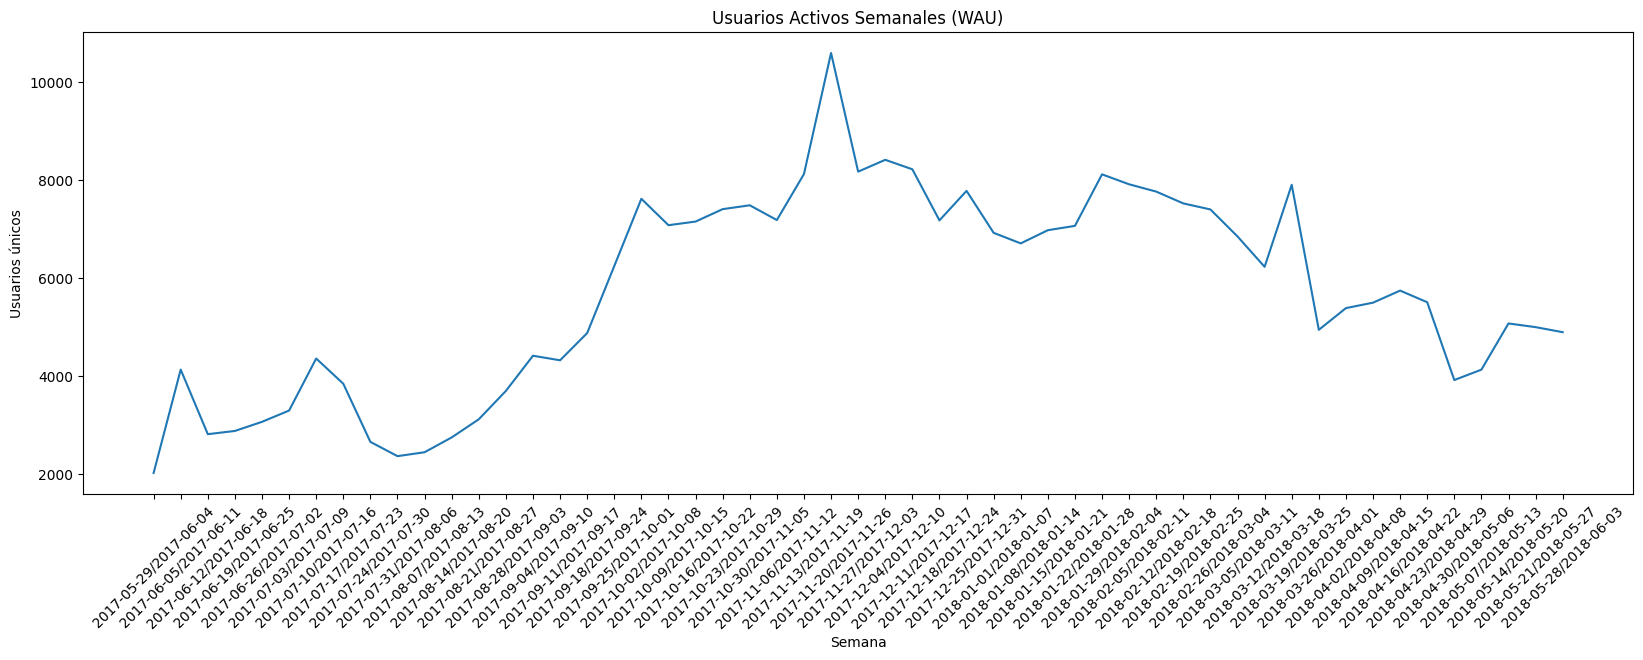

In [13]:
#Generacion de WAU

plt.figure(figsize=(20,6))
plt.plot(wau.index.astype(str), wau.values, label='WAU')
plt.title('Usuarios Activos Semanales (WAU)')
plt.xlabel('Semana')
plt.ylabel('Usuarios únicos')
plt.xticks(rotation=45)
plt.show()

#En la semana de noviembre 6 a noviembre 12 se registro un pico bastante grande de usuarios activos y normalmente la cantidad de usuarios esta arriba de 4000, salvo algunas semanas

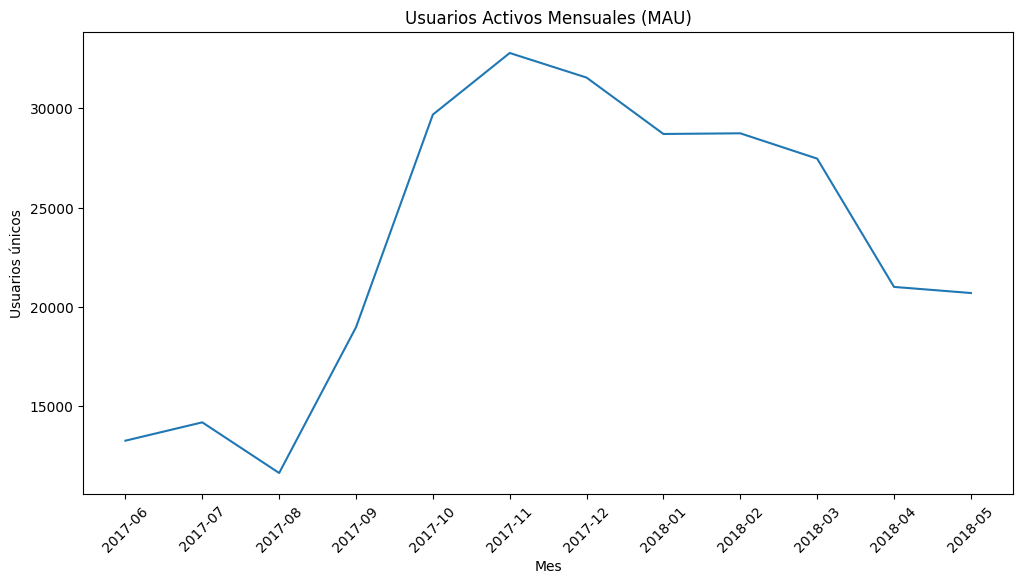

In [14]:
#Generacion de MAU

plt.figure(figsize=(12,6))
plt.plot(mau.index.astype(str), mau.values, label='MAU')
plt.title('Usuarios Activos Mensuales (MAU)')
plt.xlabel('Mes')
plt.ylabel('Usuarios únicos')
plt.xticks(rotation=45)
plt.show()

#Se puede visualizar claramente que la cantidad de usuarios activos empieza a despegar saliendo del mes de agosto del 2017, de ahi mantiene una cantidad de usuarios activos arriba de los 25000 y se empieza a bajar esa cantidad empezando marzo del año siguiente

In [15]:
#Número de sesiones por día

sessions_per_day = visits.groupby('visit_date')['uid'].count()

In [16]:
#Medidas estadisticas básicas

visits['session_duration'].describe()

count    359400.000000
mean         10.717095
std          16.618796
min         -46.000000
25%           2.000000
50%           5.000000
75%          14.000000
max         711.000000
Name: session_duration, dtype: float64

In [17]:
#Duración promedio de sesión

visits['session_duration'].mean()

np.float64(10.717094787608978)

#El tiempo promedio de cada usuario es de 10.71 min, pero con los demas datos se puede deducir que si es juy variable para cada uno, algunos pueden ser demasiados rapidos y el maximo fue de 711 min, ese ultimo puede haber dejado sin querer la pagina abierta.

In [18]:
#Frecuencia de retorno

user_sessions = visits.groupby('uid').size()
user_sessions.describe()

count    228169.000000
mean          1.575148
std           4.646800
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max         893.000000
dtype: float64

In [19]:
#Media de usuarios recurrentes

(user_sessions > 1).mean()

np.float64(0.2284622363248294)

#El porcentaje de los usuarios que regresan a visitar la pagina es del %22.8 (Entre 22-23%), esto significa que en 78-77% restante solo utiliza la pagina una vez

In [20]:
#Primer visita y primera compra

first_visit = visits.groupby('uid')['start_ts'].min()
first_order = orders.groupby('uid')['buy_ts'].min()

conversion = pd.concat([first_visit, first_order], axis=1)
conversion.columns = ['first_visit', 'first_order']

conversion['conversion_days'] = (
    conversion['first_order'] - conversion['first_visit']
).dt.days

In [21]:
#Dias que pasaron para su primer comp

conversion['conversion_days'].value_counts().sort_index()

conversion_days
0.0      26363
1.0       1011
2.0        563
3.0        434
4.0        324
         ...  
354.0        1
355.0        3
357.0        4
362.0        1
363.0        1
Name: count, Length: 345, dtype: int64

#El primer digito equivale a la cantidad de dias que pasaron antes de que el usuario realizara su primer compra, traducido seria asi:
*En la primer visita fueron 26363 usuarios los que realizaron una compra
*En la segunda visita fueron 1011
*En la tercer visita son 563 usuarios los que realizaron compra


In [22]:
#Estadisticas de pedidos por usuario

orders_per_user = orders.groupby('uid').size()
orders_per_user.describe()

count    36523.000000
mean         1.380363
std          3.454461
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max        239.000000
dtype: float64

In [23]:
#Media de pedidos por usuario

orders['revenue'].mean()

np.float64(4.999646930477041)

#En promedio, un usuario compra 5 boletos cada que entra, pero de nuevo la desviacion estandar es muy alta por lo cual hay valores que tienden a inflarse, el mejor ejemplo es que el usuario con mayor cantidad de ventas fue de 239 entradas

In [24]:
#Promedio de ingreso por usuario

ltv = orders.groupby('uid')['revenue'].sum()
ltv.mean()

np.float64(6.901327930345262)

#Por cada usuario se registra $6.90 de ingreso a la compañia

In [25]:
#Gasto total en Marketing

total_cost = costs['costs'].sum()
print(total_cost)

329131.62


#El gasto total que se realizo por todo el marketing fue de $329,131.62

In [26]:
#Gasto por canal

cost_by_source = costs.groupby('source_id')['costs'].sum()
print(cost_by_source)

source_id
1      20833.27
2      42806.04
3     141321.63
4      61073.60
5      51757.10
9       5517.49
10      5822.49
Name: costs, dtype: float64


#Con esta metrica se puede visualizar que el canal 3 es el que mayor cantidad de marketing entra ($141,321.63), le sigue el 4 pero con una cantidad mucho menor que la mitad del mayor. Y por otro lado se puede visualizar que hay 2 canales (9 y 10) que estan muy por debajo de los otros

In [27]:
#Clientes por canal

first_source = visits.sort_values('start_ts').groupby('uid').first()

customers_by_source = first_source['source_id'].value_counts()
print(customers_by_source)

source_id
4     72346
3     66116
5     49237
2     17616
1      9469
10     6903
9      6448
7        32
6         2
Name: count, dtype: int64


In [28]:
#Generacion de grafico comparativo entre canales y clientes

#Union de tablas
comparison = pd.concat([cost_by_source, customers_by_source], axis=1)
comparison.columns = ['total_cost', 'customers']
comparison = comparison.fillna(0)

print(comparison)

           total_cost  customers
source_id                       
1            20833.27       9469
2            42806.04      17616
3           141321.63      66116
4            61073.60      72346
5            51757.10      49237
9             5517.49       6448
10            5822.49       6903
7                0.00         32
6                0.00          2


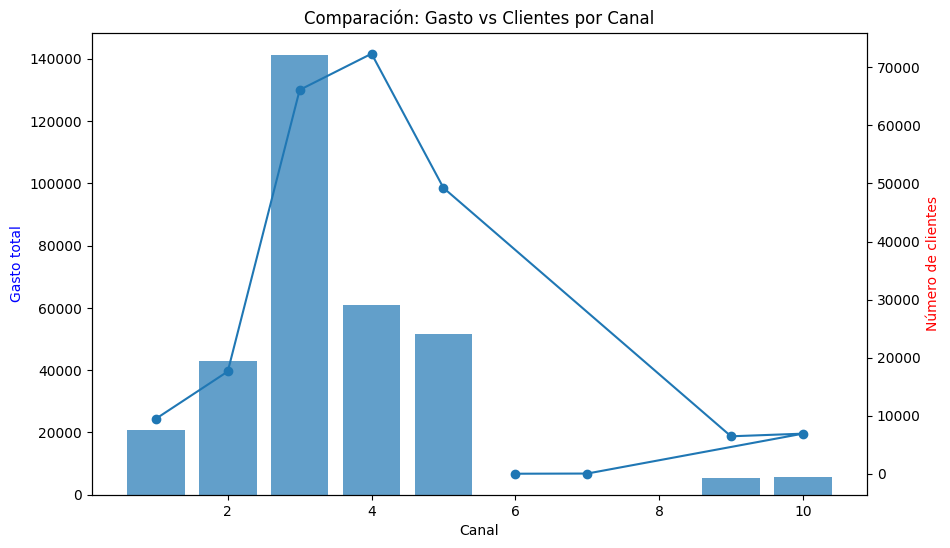

In [29]:
#Creacion de grafica

import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10,6))

# Barras para gasto
ax1.bar(comparison.index, comparison['total_cost'], alpha=0.7)
ax1.set_xlabel('Canal')
ax1.set_ylabel('Gasto total', color='blue')
ax1.tick_params(axis='y')

# Segundo eje para clientes
ax2 = ax1.twinx()
ax2.plot(comparison.index, comparison['customers'], marker='o')
ax2.set_ylabel('Número de clientes', color='red')

plt.title('Comparación: Gasto vs Clientes por Canal')
plt.show()

#El canal 4 corresponde al canal con mayor cantidad de clientes, pero lo que destaca es que la cantidad de gasto en este canal es menor que el gasto mayor que corresponde al 3, lo cual puede ser una area de oportunidad para maximizar esfuerzos en ese canal, o bien recortar gastos en el canal 3 que tiene menor cantidad de clientes y aprovecharlos en otros

In [30]:
#CAC

cac = cost_by_source / customers_by_source
print(cac)

source_id
1     2.200155
2     2.429952
3     2.137480
4     0.844188
5     1.051183
6          NaN
7          NaN
9     0.855690
10    0.843472
dtype: float64


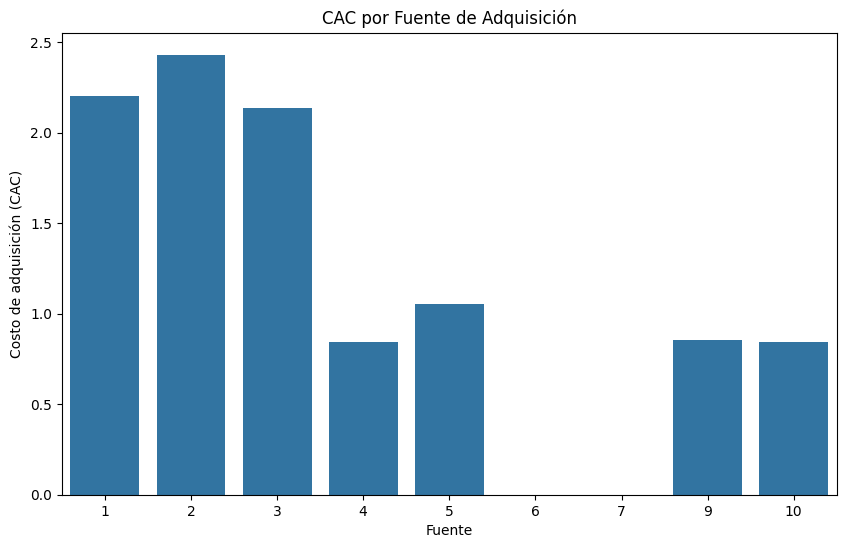

In [31]:
#Graficando el CAC

plt.figure(figsize=(10,6))
sns.barplot(x=cac.index, y=cac.values)
plt.title('CAC por Fuente de Adquisición')
plt.xlabel('Fuente')
plt.ylabel('Costo de adquisición (CAC)')
plt.show()

#Considerando el promedio que ingresa un cliente como $6.90, se puede ver que todos los canales logran el objetivo, pero destacan que los canales 1 y 2 son los que maximizan la ganancia

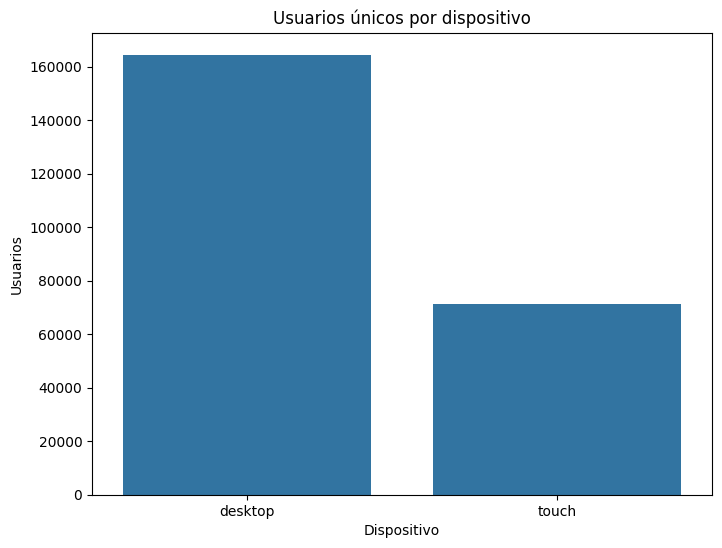

In [32]:
#Grafico por dispositivo

device_users = visits.groupby('device')['uid'].nunique()

plt.figure(figsize=(8,6))
sns.barplot(x=device_users.index, y=device_users.values)
plt.title('Usuarios únicos por dispositivo')
plt.xlabel('Dispositivo')
plt.ylabel('Usuarios')
plt.show()

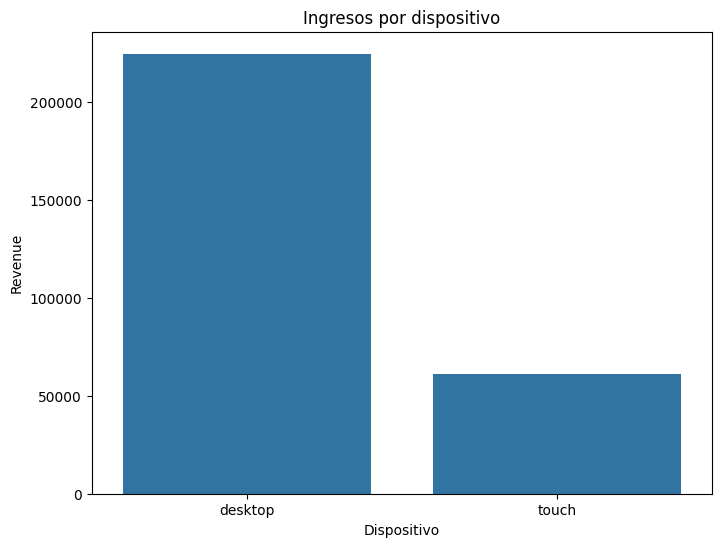

In [33]:
#Comprobar los ingresos por dispositivo

orders_device = orders.merge(
    visits[['uid','device']].drop_duplicates(),
    on='uid'
)

revenue_device = orders_device.groupby('device')['revenue'].sum()

#Grafica de ingresos por dispositivo
plt.figure(figsize=(8,6))
sns.barplot(x=revenue_device.index, y=revenue_device.values)
plt.title('Ingresos por dispositivo')
plt.xlabel('Dispositivo')
plt.ylabel('Revenue')
plt.show()

#Este grafico solo es un extra para visualizar por que medio se genera mas visitas, ya que en un momento dado tambien se puede utilizar para marketing, en este caso se nota que es mas usual que los usuarios entren por medio de computadora antes que celular por mas del doble de diferencia, y en ingreso tambien se nota, los ingresos por celular no superan los 100,000 mientras que en computadora son mas de 200,000

In [34]:
#ROMI

orders_source = orders.merge(first_source[['source_id']], 
                             left_on='uid', 
                             right_index=True)

revenue_by_source = orders_source.groupby('source_id')['revenue'].sum()

romi = (revenue_by_source - cost_by_source) / cost_by_source
print(romi)

source_id
1     0.492351
2     0.096191
3    -0.614275
4    -0.071664
5     0.016750
7          NaN
9     0.043844
10   -0.235665
dtype: float64


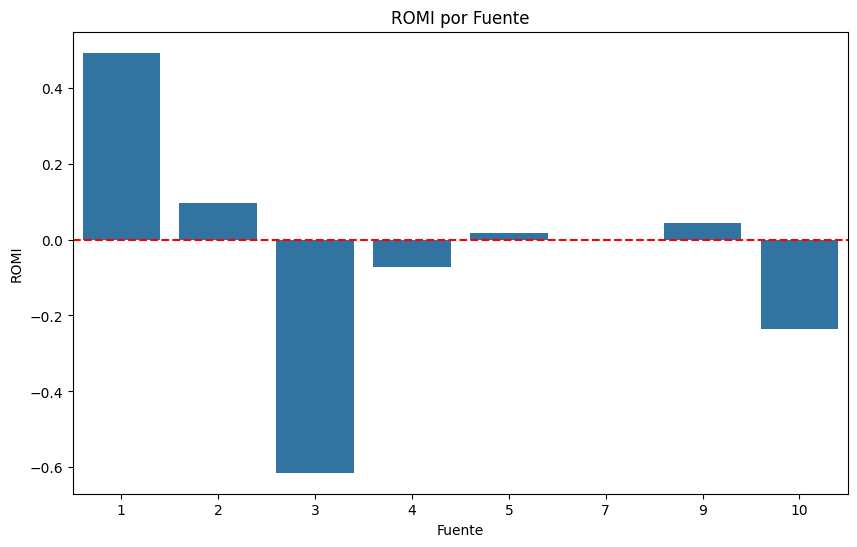

In [35]:
#Tabla de ROMI

plt.figure(figsize=(10,6))
sns.barplot(x=romi.index, y=romi.values)
plt.axhline(0, color='red', linestyle='--')
plt.title('ROMI por Fuente')
plt.xlabel('Fuente')
plt.ylabel('ROMI')
plt.show()

#Con este parametro ya es mas facil ver la ganancia propia de ganancia por marketing, en definitiva el canal 3 tiene una perdida del -%61, lo cual es una fuga de ganancias y por el contrario el canal 1 que es uno de los que menor se gana en marketing es el que mas ganancia genera.

#En conclusion con el ROMI, en el canal 4 hay que hacer recorte de presupuesto si o sí y meterlo en el canal 1 y 2, el dos es por que puede ser tambien un area de oportunidad ya que no presenta perdidas y se podria probar si puede maximizar ganancias, el canal 4 no tiene perdidas tan grandes pero las tiene, por lo cual se podria hacer un recorte moderado de presupuesto y ver que tal funcionaria.

In [37]:
#Graficar LTV

#Obtener LTV por canal
ltv_by_source = orders_source.groupby('source_id')['revenue'].sum() / \
                customers_by_source

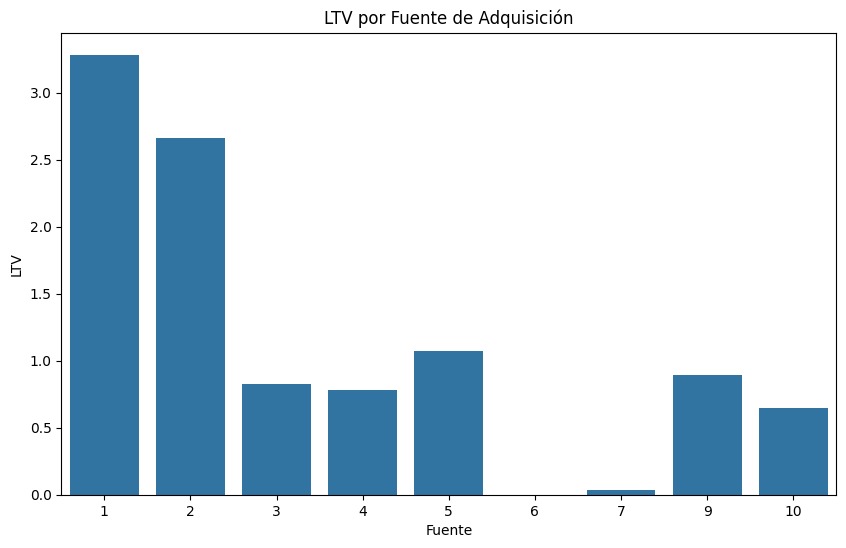

In [38]:
#Grafica de LTV
plt.figure(figsize=(10,6))
sns.barplot(x=ltv_by_source.index, y=ltv_by_source.values)
plt.title('LTV por Fuente de Adquisición')
plt.xlabel('Fuente')
plt.ylabel('LTV')
plt.show()

#Concuerda con el ROMI, el canal 1 es el que mas otorga

Conclusión

#El dispositivo que mas e utiliza es la computadora, superando por un amplio margen al celular, ya dentro de este el canal 1 es el mas util, ya que genera mayor cantidad ed ganancia apesar de que tiene menos clientes , en su contrario el canal 3 es un canal que genera perdidas grandes por lo cual se debe reestructurar la cantidad de recursos a este canal pues no estan dado resultados y moverlos a las areas de oportunidad como el canal 1 y se puede intentar u poco en el canal 2 tambien como area de oportunidad, pero priorizando en canal 1. El canal 4 tiene una base fuerte de usuarios pero no estan generando ganancia con el marketing por lo cual es una buena opción hacer un recorte de presupuesto en ese canal

#Las fechas mas fuertes para la venta de eventos corresponden a fechas en que hay bastante gente de vacaciones, por lo cual es una buena opcion invertir en ellas pues la gente quiere espectaculos.